1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense


2.1 Creating Datasets

In [2]:
# Generate 2000 non-linear samples
X, y = make_moons(
    n_samples=2000,
    noise=0.12,
    random_state=42
)

# Create DataFrame in the same format as your image
df = pd.DataFrame({
    'X': X[:, 0],
    'Y': X[:, 1],
    'Class': y.astype(float)
})

df.head()

,X,Y,Class
0,1.750613,0.215969,1.0
1,0.388455,0.937320,0.0
2,0.494370,-0.308781,1.0
3,-0.947407,0.137360,0.0
4,0.504882,-0.348035,1.0


2.2 Visualize the Dataset

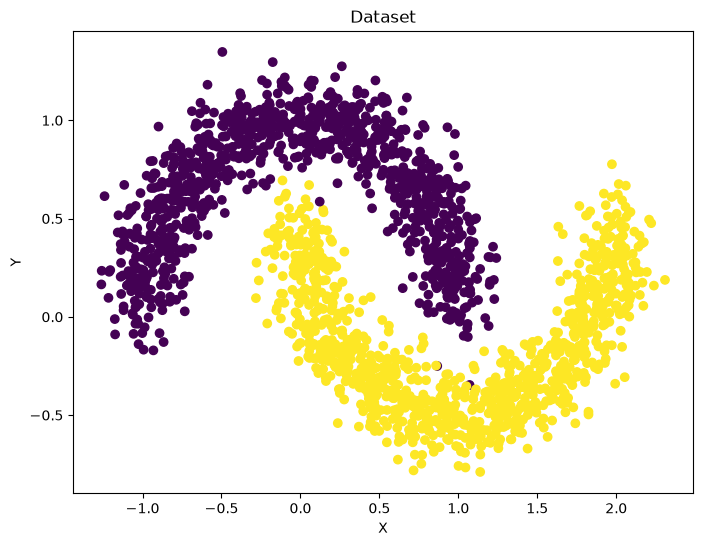

In [3]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df['X'],
    df['Y'],
    c=df['Class']
)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Dataset')
plt.show()

3. Separate Features and Target

In [4]:
X = df.iloc[:, 0:2].values
y = df.iloc[:, -1].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2000, 2)
y shape: (2000,)


4. Create Neural Network with ReLU

In [8]:
model = Sequential()

model.add(
    Dense(
        10,
        activation='sigmoid',
        input_shape=(2,)
    )
)

model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

5. Model Summary

In [9]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

6. Check Initial Weights

In [10]:
model.get_weights()

[array([[ 0.2047602 , -0.6881299 , -0.11918235,  0.0845083 ,  0.6050109 ,
         -0.39174366,  0.3033095 , -0.00512522, -0.5584618 , -0.12253946],
        [-0.20028013, -0.10650223, -0.5957292 ,  0.5048041 ,  0.1716513 ,
          0.16585088,  0.06977665, -0.3523451 ,  0.48075134,  0.4272763 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.08756596],
        [ 0.33331937],
        [-0.25065702],
        [-0.7245869 ],
        [-0.4077243 ],
        [ 0.40754467],
        [ 0.31632644],
        [ 0.36743003],
        [-0.23461336],
        [-0.52978873]], dtype=float32),
 array([0.], dtype=float32)]

7. Store the Weights

In [11]:
initial_weights = model.get_weights()

8. Set All Weights and Biases to ZERO

In [12]:
initial_weights[0] = np.zeros(
    model.get_weights()[0].shape
)

initial_weights[1] = np.zeros(
    model.get_weights()[1].shape
)

initial_weights[2] = np.zeros(
    model.get_weights()[2].shape
)

initial_weights[3] = np.zeros(
    model.get_weights()[3].shape
)

9. Set Zero Weights in the Model

In [13]:
model.set_weights(initial_weights)

In [14]:
model.get_weights()

[array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

10. Compile the Model

In [15]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

11. Train the Model

In [16]:
history = model.fit(
    X,
    y,
    epochs=100,
    validation_split=0.2
)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4888 - loss: 0.6934 - val_accuracy: 0.4550 - val_loss: 0.6937
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5113 - loss: 0.6931 - val_accuracy: 0.4550 - val_loss: 0.6947
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5113 - loss: 0.6925 - val_accuracy: 0.4550 - val_loss: 0.6953
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5113 - loss: 0.6905 - val_accuracy: 0.4550 - val_loss: 0.6951
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5113 - loss: 0.6861 - val_accuracy: 0.4550 - val_loss: 0.6919
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5113 - loss: 0.6787 - val_accuracy: 0.4550 - val_loss: 0.6858
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5113 - loss: 0.6683 - val_accuracy: 0.4550 - val_loss: 0.6760
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5113 - loss: 0.6550 - val_accuracy: 0.4550 - v

12. Check the Weights After Training

In [17]:
model.get_weights()

[array([[-0.71122575, -0.71122575, -0.71122575, -0.71122575, -0.71122575,
         -0.71122575, -0.71122575, -0.71122575, -0.71122575, -0.71122575],
        [ 3.1960876 ,  3.1960876 ,  3.1960876 ,  3.1960876 ,  3.1960876 ,
          3.1960876 ,  3.1960876 ,  3.1960876 ,  3.1960876 ,  3.1960876 ]],
       dtype=float32),
 array([-1.3557453, -1.3557453, -1.3557453, -1.3557453, -1.3557453,
        -1.3557453, -1.3557453, -1.3557453, -1.3557453, -1.3557453],
       dtype=float32),
 array([[-0.842949],
        [-0.842949],
        [-0.842949],
        [-0.842949],
        [-0.842949],
        [-0.842949],
        [-0.842949],
        [-0.842949],
        [-0.842949],
        [-0.842949]], dtype=float32),
 array([2.6362982], dtype=float32)]

13. Check the Predictions

In [18]:
predictions = model.predict(X, verbose=1)

predictions[:10]

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[0.82485557],
       [0.01668107],
       [0.89115506],
       [0.2555845 ],
       [0.89709157],
       [0.87754905],
       [0.13084489],
       [0.9147008 ],
       [0.40362498],
       [0.8903625 ]], dtype=float32)

14. Plot Training Loss

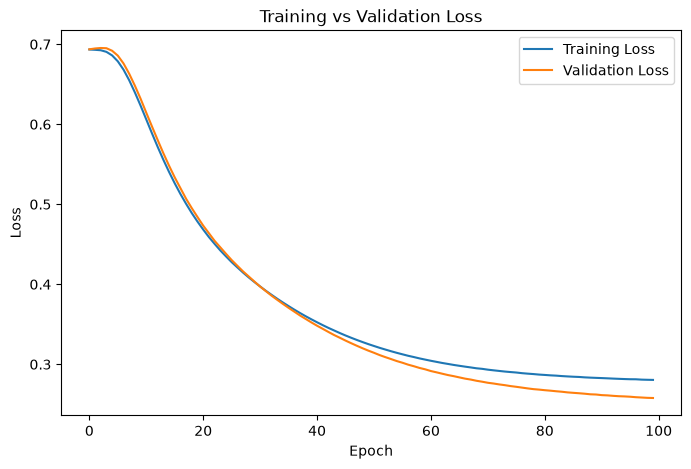

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')

plt.legend([
    'Training Loss',
    'Validation Loss'
])

plt.show()

15. Plot Accuracy

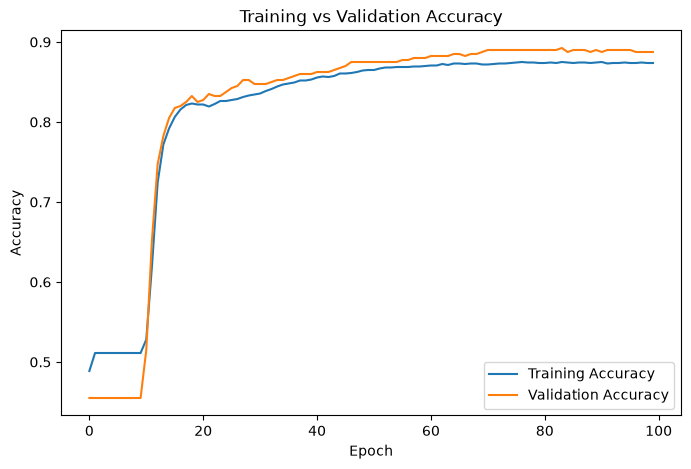

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')

plt.legend([
    'Training Accuracy',
    'Validation Accuracy'
])

plt.show()

16. Decision Boundary

In [21]:
from mlxtend.plotting import plot_decision_regions

class MyModel:

    def __init__(self, model):
        self.model = model

    def predict(self, X):
        pred = self.model.predict(
            X,
            verbose=0
        )

        return (
            pred >= 0.5
        ).astype(int).ravel()

17. Create Classifier

In [22]:
clf = MyModel(model)

18. Plot Decision Regions

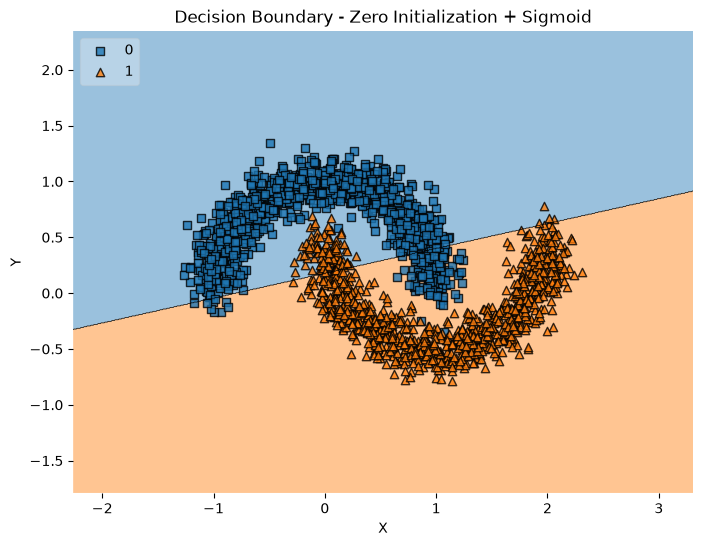

In [24]:
plt.figure(figsize=(8, 6))

plot_decision_regions(
    X,
    y.astype(int),
    clf=clf,
    legend=2
)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Decision Boundary - Zero Initialization + Sigmoid')

plt.show()